# Error Analysis: K-Means

- **Question:** Can we clearly separate predictions vs non-predictions based on embeddings alone?

In [ ]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
# combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/combined_generated_fin_phrase_bank')
train_data = os.path.join(base_data_path, 'classification_results/train_synthetic-v1_2026-03-23/seed3')

In [4]:
# model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
test_data = os.path.join(train_data, 'external_fpb-maya-binary-imbalanced-96d-v1/', 'ml_classifiers_fpb-maya-binary-imbalanced-96d-v1.csv')

model_results_df = DataProcessing.load_from_file(test_data, 'csv', sep=',')
cols_to_drop = ["Dataset Name", "Author Type", "maya_label"]
compare_y_vs_yhats_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)
compare_y_vs_yhats_df.head(3)

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1


In [5]:
if "Sentence Label" in compare_y_vs_yhats_df.columns:
    print(True)

True


## Plot Clusters

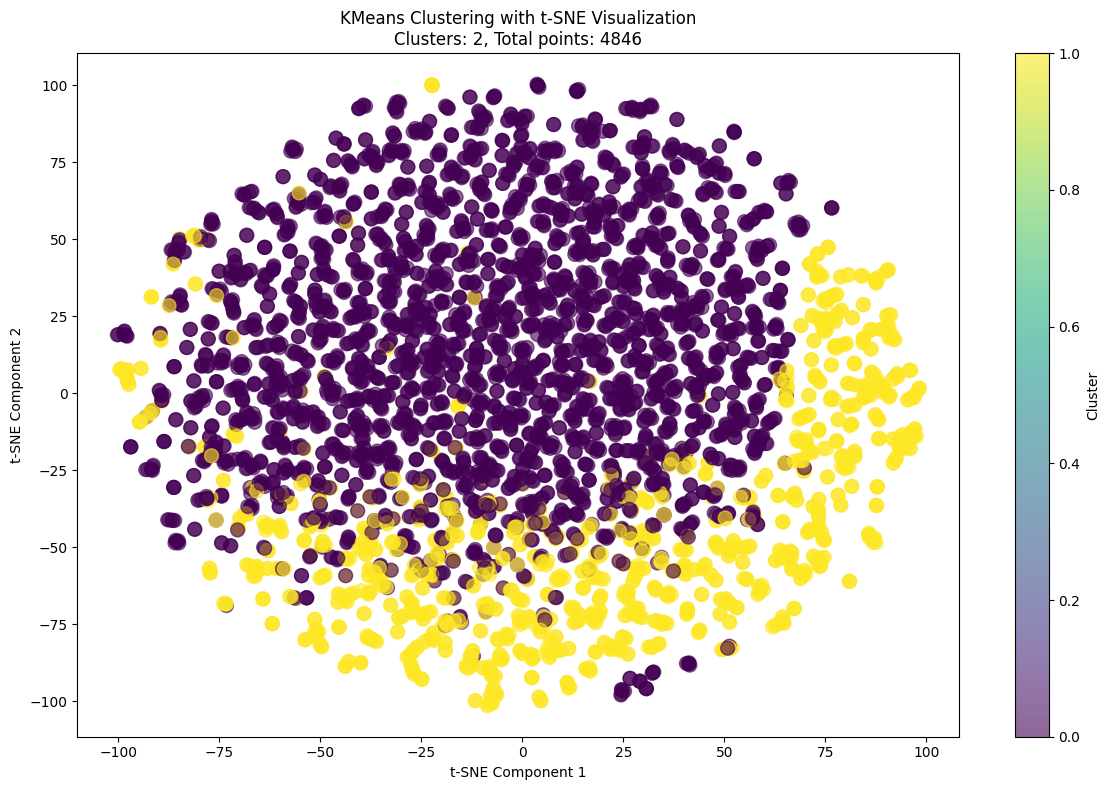


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [0] Currently the quarterly applied surcharges differ significantly from the actual market prices .
  - [0] `` Fixed Mobile Convergence solutions represent a key value proposition in today 's communication market .
  - [0] Nevertheless , the development can not be allowed to ruin the print newspaper , which continues to be Sanoma News ' main medium .
  - [1] Jens Schulte-Bockum , Vodafone 's global director of terminals , said the company expects to sell one to two million of the Vodafone 125 and 225 models in the first year of launch , and potentially tens of millions over the lifetime of the device .
  - [1] The second-quarter net sales are expected to be on par with the first quarter of 2009 .
  - [1] Hearst will be able to consolidate about 20 % of all Russian market for advertising in press afte

In [6]:
DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label'
    )

## Takeaways

1. Since imbalanced data set (90.5% non-predictions and 9.5% predictions), the skewness of non-predictions to predictions for each cluster is valid.
2. Visually, the embeddings, are somewhat linearly separable because majority of the purple are above and majority of the yellow are below, which suggests embeddings capture some underlying semantic structure, but further sentence-level analysis is needed to determine whether that structure corresponds to the prediction/non-prediction distinction.
3. Embeddings alone are not enough, so need futher analyses at sentence-level.
